# VQCFD Variance Analysis

Notebook for comparing `variance`-mode results across different `(N, L)` runs using the refactored saved data structure.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Any
import re

import numpy as np
import matplotlib.pyplot as plt
import yaml

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True

In [2]:
REPO_ROOT = Path.cwd()
RESULTS_ROOT = REPO_ROOT / 'results'
RESULTS_ROOT

PosixPath('/Users/joel/Documents/MA/Code/VQCFD/results')

In [3]:
def _safe_yaml(path: Path) -> dict[str, Any]:
    if not path.exists():
        return {}
    with path.open('r', encoding='utf-8') as fh:
        return yaml.safe_load(fh) or {}


def _full_label(dir_label: str, label: str) -> str:
    return f'{dir_label}_{label}'


def load_variance_run(dir_label: str, label: str) -> dict[str, Any]:
    results_dir = RESULTS_ROOT / f'results_{dir_label}'
    data_dir = results_dir / f'data_{label}'
    full = _full_label(dir_label, label)
    values = _safe_yaml(data_dir / f'values_{full}.yaml')
    manifest = _safe_yaml(results_dir / f'manifest_{full}.yaml')
    variance_path = data_dir / f'variance_{full}.npy'
    variance_arr = np.load(variance_path, allow_pickle=True) if variance_path.exists() else None
    variance_val = None
    if variance_arr is not None:
        variance_val = float(np.asarray(variance_arr).reshape(()))
    elif 'variance' in values:
        variance_val = float(values['variance'])
    return {
        'dir_label': dir_label,
        'label': label,
        'full_label': full,
        'data_dir': data_dir,
        'values': values,
        'manifest': manifest,
        'n': values.get('n', manifest.get('n')),
        'l': values.get('l', manifest.get('l')),
        'mode': values.get('mode', manifest.get('mode')),
        'variance': variance_val,
        'variance_tries': values.get('variance_tries'),
        'variance_num_samples': values.get('variance_num_samples'),
        'variance_runtime_s': values.get('variance_runtime_s'),
    }

In [4]:
def discover_variance_runs(results_root: Path = RESULTS_ROOT):
    rows = []
    for results_dir in sorted(results_root.glob('results_*')):
        dir_label = results_dir.name.removeprefix('results_')
        for data_dir in sorted(results_dir.glob('data_*')):
            label = data_dir.name.removeprefix('data_')
            full = _full_label(dir_label, label)
            values = _safe_yaml(data_dir / f'values_{full}.yaml')
            manifest = _safe_yaml(results_dir / f'manifest_{full}.yaml')
            mode = values.get('mode', manifest.get('mode'))
            has_variance_file = (data_dir / f'variance_{full}.npy').exists()
            if mode == 'variance' or has_variance_file or ('variance' in values):
                row = load_variance_run(dir_label, label)
                rows.append(row)
    rows.sort(key=lambda r: (r['n'] if r['n'] is not None else 10**9, r['l'] if r['l'] is not None else 10**9, r['full_label']))
    return rows


def print_variance_runs(rows):
    for r in rows:
        print(f"{r['full_label']:<14} n={r['n']!s:<3} l={r['l']!s:<3} variance={r['variance']!s:<14} tries={r['variance_tries']!s:<6}")
    print('count=', len(rows))

In [36]:
variance_runs = discover_variance_runs()
print_variance_runs(variance_runs)

var_N2L1       n=2   l=1   variance=0.31716497156749646 tries=4000  
var_N2L2       n=2   l=2   variance=0.2965365373132682 tries=4000  
var_N2L4       n=2   l=4   variance=0.279785533622202 tries=4000  
var_N2L8       n=2   l=8   variance=0.27073325456218755 tries=2000  
var_N3L1       n=3   l=1   variance=0.1442779785519855 tries=1000  
var_N3L2       n=3   l=2   variance=0.13890475032056604 tries=1000  
var_N3L4       n=3   l=4   variance=0.13305193118477224 tries=1000  
var_N3L8       n=3   l=8   variance=0.1279561159880521 tries=1000  
var_N4L1       n=4   l=1   variance=0.06925700385211589 tries=1000  
var_N4L2       n=4   l=2   variance=0.0664977257100345 tries=1000  
var_N4L4       n=4   l=4   variance=0.0645757131423228 tries=1000  
var_N4L8       n=4   l=8   variance=0.06348565427160001 tries=1000  
var_N5L1       n=5   l=1   variance=0.03287471806847357 tries=1000  
var_N5L2       n=5   l=2   variance=0.032665033081435625 tries=1000  
var_N5L4       n=5   l=4   variance=0.03

In [58]:
# Manual selection (recommended when you want a controlled comparison)
RUNS = [
    # ('var', 'N2L1'),('var', 'N3L1'),('var', 'N4L1'),('var', 'N5L1'),
    # ('var', 'N2L2'),('var', 'N3L2'),('var', 'N4L2'),('var', 'N5L2'),#('var', 'N6L2'),('var', 'N7L2'),('var', 'N8L2'),('var', 'N9L2'),('var', 'N10L2'),
    # ('var', 'N2L4'),('var', 'N3L4'),('var', 'N4L4'),('var', 'N5L4'),
    # ('var', 'N2L8'),('var', 'N3L8'),('var', 'N4L8'),('var', 'N5L8'),
    # ('N9', 'L2'),  # if a variance run was saved under a different dir_label/label pattern
]

selected = [load_variance_run(d, l) for d, l in RUNS] if RUNS else variance_runs
print_variance_runs(selected)

# Build a simple table-like list for plotting
rows = [r for r in selected if r.get('variance') is not None and r.get('n') is not None and r.get('l') is not None]

var_N2L1       n=2   l=1   variance=0.31716497156749646 tries=4000  
var_N2L2       n=2   l=2   variance=0.2965365373132682 tries=4000  
var_N2L4       n=2   l=4   variance=0.279785533622202 tries=4000  
var_N2L8       n=2   l=8   variance=0.27073325456218755 tries=2000  
var_N3L1       n=3   l=1   variance=0.1442779785519855 tries=1000  
var_N3L2       n=3   l=2   variance=0.13890475032056604 tries=1000  
var_N3L4       n=3   l=4   variance=0.13305193118477224 tries=1000  
var_N3L8       n=3   l=8   variance=0.1279561159880521 tries=1000  
var_N4L1       n=4   l=1   variance=0.06925700385211589 tries=1000  
var_N4L2       n=4   l=2   variance=0.0664977257100345 tries=1000  
var_N4L4       n=4   l=4   variance=0.0645757131423228 tries=1000  
var_N4L8       n=4   l=8   variance=0.06348565427160001 tries=1000  
var_N5L1       n=5   l=1   variance=0.03287471806847357 tries=1000  
var_N5L2       n=5   l=2   variance=0.032665033081435625 tries=1000  
var_N5L4       n=5   l=4   variance=0.03

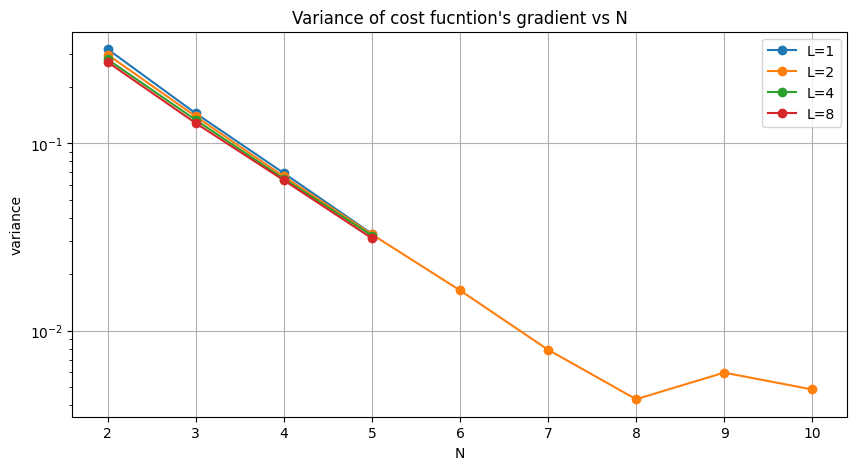

In [ ]:
# Plot 1: Variance vs N, grouped by L
from collections import defaultdict

by_L = defaultdict(list)
for r in rows:
    by_L[int(r['l'])].append(r)

plt.figure(figsize=(10, 5))
for L, group in sorted(by_L.items()):
    group = sorted(group, key=lambda r: int(r['n']))
    xs = [int(r['n']) for r in group]
    ys = [float(r['variance']) for r in group]
    plt.plot(xs, ys, marker='o', label=f'L={L}')

plt.title('Variance of cost fucntion\'s gradient vs N')
plt.xlabel('N')
plt.ylabel('variance')
plt.yscale('log')
plt.legend()


#plt.savefig(f"figures/variance/variance_vs_N_all.pdf", bbox_inches='tight')

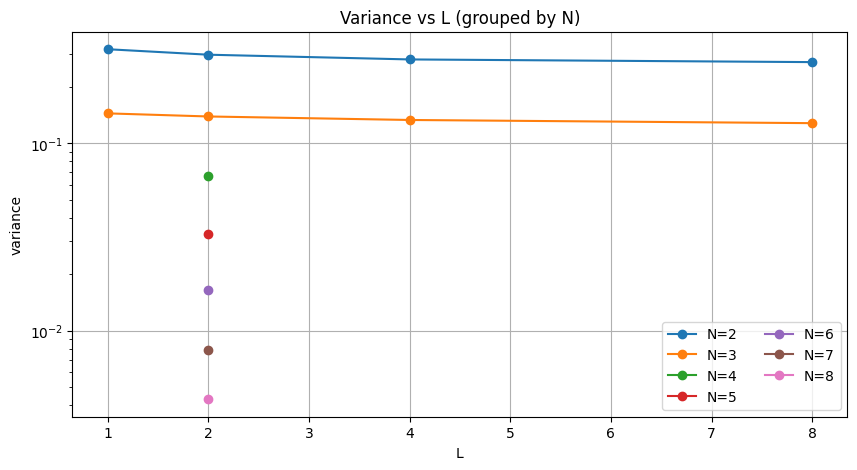

In [35]:
# Plot 2: Variance vs L, grouped by N
from collections import defaultdict

by_N = defaultdict(list)
for r in rows:
    by_N[int(r['n'])].append(r)

plt.figure(figsize=(10, 5))
for N, group in sorted(by_N.items()):
    group = sorted(group, key=lambda r: int(r['l']))
    xs = [int(r['l']) for r in group]
    ys = [float(r['variance']) for r in group]
    plt.plot(xs, ys, marker='o', label=f'N={N}')

plt.title('Variance vs L (grouped by N)')
plt.xlabel('L')
plt.ylabel('variance')
plt.yscale('log')
plt.legend(ncol=2)
plt.show()

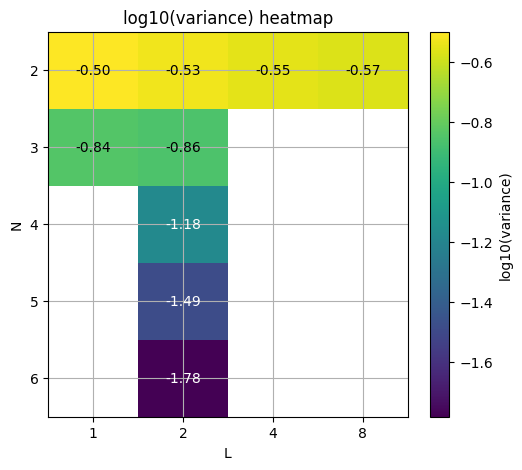

In [24]:
# Plot 3: Heatmap (N x L) of log10(variance)
if rows:
    Ns = sorted({int(r['n']) for r in rows})
    Ls = sorted({int(r['l']) for r in rows})
    grid = np.full((len(Ns), len(Ls)), np.nan, dtype=float)
    n_idx = {n:i for i,n in enumerate(Ns)}
    l_idx = {l:i for i,l in enumerate(Ls)}
    for r in rows:
        v = float(r['variance'])
        if v > 0:
            grid[n_idx[int(r['n'])], l_idx[int(r['l'])]] = np.log10(v)

    fig, ax = plt.subplots(figsize=(1 + 1.2*len(Ls), 1 + 0.8*len(Ns)))
    im = ax.imshow(grid, aspect='auto')
    ax.set_xticks(range(len(Ls)), labels=Ls)
    ax.set_yticks(range(len(Ns)), labels=Ns)
    ax.set_xlabel('L')
    ax.set_ylabel('N')
    ax.set_title('log10(variance) heatmap')

    for i in range(len(Ns)):
        for j in range(len(Ls)):
            if np.isfinite(grid[i, j]):
                ax.text(j, i, f"{grid[i,j]:.2f}", ha='center', va='center', color='white' if grid[i,j] < np.nanmean(grid) else 'black')

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('log10(variance)')
    plt.show()
else:
    print('No variance rows available.')

In [31]:
# Optional: inspect raw metadata for a specific selected run
if selected:
    r = selected[0]
    print(r['full_label'])
    print('variance =', r['variance'])
    print('values keys =', list(r['values'].keys()))
    r['values']

var_N2L1
variance = 0.31716497156749646
values keys = ['n', 'l', 'shots', 'max_iter', 't_total', 'mu', 'dt', 'plat_tol', 'patience', 'initial_params_source', 'variance', 'variance_tries', 'variance_num_samples', 'variance_runtime_s', 'shots_used_per_timestep', 'shots_used_total']
